# 00 — Where the geometry comes from

**The opening every pyCAFE example shares: one dialog, and whatever the user
picks is read.**

No physics here. This notebook is the operational answer to the first question
of any run — *how does my geometry get into pyCAFE* — and the four answers are
the four kinds of input:

| the file you pick | what pyCAFE does with it | class |
|---|---|---|
| `.msh` | **uses it as it is**: already meshed *and* already named | `MeshFile` |
| *(nothing to pick)* | **builds it from parameters**, a box or a duct stated in the script | `Library` |

This release reads gmsh meshes and nothing else. A CAD file (`CadFile`) and a
Nastran deck (`NastranFile`) are written and work, but are not part of it: see
section 4.

The last one is the case where there is no file to look for: a box, a duct, a
plate are fully described by their dimensions, so a script states them and pyCAFE
makes the mesh. Every such case is also kept, pre-built, in `Library/` — the one
folder that holds everything a run can be pointed at, meshes and CAD files and
decks together, and the folder the dialog opens on.

The order is always the same, and it is the order of this notebook: first say
**what run you want** — acoustic, or vibroacoustic — and **what the domains are
made of** (section 0), then **load the mesh or the geometry** and let pyCAFE
work out which of the four cases it is (section 1). A `ModelSpec` holds the lot,
and `build_model` meshes, validates, **draws** and assembles it.

## 0. Two questions before any file is opened

**What kind of run, and what are the domains made of.** Both are stated here,
at the top, and nothing below changes them.

* `ANALYSIS = "acoustic"` — the fluid alone: one domain, one material.
* `ANALYSIS = "vibroacoustic"` — fluid **and** structure, coupled: two domains,
  so two materials. The plate radiates into the fluid and the fluid loads it
  back; that is the whole point of the coupling.

(`"auto"` is also accepted and reads the kind from the groups the mesh turns
out to have. Stating it is better: a geometry that cannot serve the run you
meant is then refused, instead of quietly downgraded to the one it can.)

The materials go with the domains, one each: a `Fluid` (density and speed of
sound) and a `Structure` (thickness, $E$, $\nu$, density, and how its edge is
held). `AIR`, `WATER`, `aluminium(t)` and `steel(t)` are the ready-made ones.

`support="clamped"` belongs to the material block and not to the mesh on
purpose: the mesh only says **which** nodes are held — the group `plate_clamp`
— and this says **how**.

Every example opens with this same block, in this order: path bootstrap,
imports (standard library, third party, pyCAFE), the run and its materials,
then the geometry. Which names are imported changes from notebook to notebook;
the block and its order do not.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))          # run from examples/

import numpy as np
import matplotlib.pyplot as plt

import pycafe
from pycafe.core.model_spec import (
    AIR, WATER, CadFile, GEOMETRY_SUFFIXES, Library, MeshFile, ModelSpec,
    NastranFile, aluminium, build_mesh, build_model, describe_domains,
    geometry_from_file, materials_from_deck, preview, steel,
)
from pycafe.create_geom import (
    GEOMETRIES, ask_for_file, ask_for_geometry, describe_conventions,
    inspect_bdf, inspect_cad, list_groups,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

# what kind of run: "acoustic" (the fluid alone) or "vibroacoustic" (fluid and
# structure, coupled)
ANALYSIS = "vibroacoustic"

# one material per domain of that run
FLUID = AIR                                            # the acoustic domain
STRUCTURE = (aluminium(t=2.0e-3, support="clamped")    # the structural domain
             if ANALYSIS == "vibroacoustic" else None)

F_MAX = 200.0                            # highest frequency of interest [Hz]
LIBRARY = os.path.abspath("../Library")  # meshes, CAD files and decks, together

print(f"{ANALYSIS} run up to {F_MAX:.0f} Hz")
print(f"  fluid      {FLUID.name}: rho0 = {FLUID.rho0} kg/m3, "
      f"c0 = {FLUID.c0} m/s")
if STRUCTURE is None:
    print("  structure  none: an acoustic run has one domain")
else:
    print(f"  structure  {STRUCTURE.name}: t = {STRUCTURE.t * 1e3:.2f} mm, "
          f"E = {STRUCTURE.E / 1e9:.0f} GPa, nu = {STRUCTURE.nu}, "
          f"rho = {STRUCTURE.rho_s} kg/m3, {STRUCTURE.support}")
print()
print("pyCAFE reads:", ", ".join(sorted(GEOMETRY_SUFFIXES)))
print("and builds:  ", ", ".join(sorted(GEOMETRIES)))

vibroacoustic run up to 200 Hz
  fluid      air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure  aluminium: t = 2.00 mm, E = 70 GPa, nu = 0.33, rho = 2700.0 kg/m3, clamped

pyCAFE reads: .bdf, .brep, .dat, .iges, .igs, .msh, .nas, .step, .stp
and builds:   box_cavity, box_with_plate, duct_2d, duct_with_flush_plate, plate


## 1. Load the mesh, or the geometry — pyCAFE works out which

One dialog, and **what you pick decides what happens to it**. That is the whole
of the geometry stage:

* a **mesh** (`.msh`) — one from `Library/`, or any other — is already meshed
  *and* already named: it is used as it stands;
* a **Nastran deck** (`.bdf`, `.nas`) is already meshed too, but carries no
  physical groups, so the roles are read from its property cards;
* a **CAD file** (`.step`, `.stp`, `.iges`, `.brep`) is not meshed at all:
  pyCAFE meshes it here, at the size `F_MAX` asks for. It carries no roles
  either, and no way to read them — that one has to be told.

`ask_for_geometry` is the `uigetfile` of pyCAFE: it opens the native dialog on
`Library/` — the one folder that holds everything a run can be pointed at, the
meshes pyCAFE builds *and* the CAD files and decks it is given — and returns the
source that reads whatever was picked. With no display the same question is
asked on the console.

**There is no fallback file.** Cancel the dialog, or answer nothing, and the
call raises: loading some other geometry than the one meant is the one outcome
worth ruling out, because every number after it would still look reasonable.
For a run with nobody at the keyboard — CI, or this notebook executed by
`nbconvert`, which is how the stored output below was produced — the answer
comes from the environment instead, one variable per kind of file:

```bash
export PYCAFE_FILE_GEOMETRY=Library/box_with_plate.msh
export PYCAFE_FILE_CAD=Library/Tubo_1m_1m.stp
export PYCAFE_FILE_NASTRAN=Library/demo_cavity.bdf
```

In [2]:
geometry = ask_for_geometry()      # a dialog; no answer, no geometry
print()
print(type(geometry).__name__)
print(geometry)

using /Users/danielefabbri/Desktop/pycafe_new/Library/box_with_plate.msh
box_with_plate.msh: a mesh, used as it is (its physical groups already carry the roles).

MeshFile
MeshFile(path=PosixPath('/Users/danielefabbri/Desktop/pycafe_new/Library/box_with_plate.msh'), rename={}, drop=())


### Which two domains did we get?

Now the two halves meet. The input says which physical groups exist and what
role each one plays; section 0 says what they are made of. `build_mesh` meshes
(or simply checks, when there is nothing to mesh) and validates **against
`ANALYSIS`**, and `describe_domains` puts the pairing on one screen:

* `ANALYSIS = "vibroacoustic"` needs a fluid group *and* a structural group. If
  the input has only one of them, the mesh is refused right here — see the cell
  after next — instead of failing three steps later inside an assembly.
* `ANALYSIS = "acoustic"` needs the fluid only; a structural group present in
  the mesh is simply not assembled.

A deck is the one input that can fill in the materials itself: thickness and
`MAT1`/`MAT10` cards are in the file, so what section 0 left out is taken from
there (and what section 0 states wins, with the disagreement reported).

In [3]:
spec = ModelSpec(
    geometry=geometry,
    analysis=ANALYSIS,                  # what to look for, and to assemble
    fluid=FLUID,
    structure=STRUCTURE,
    f_max=F_MAX,
    work_dir=".",
)
mesh_path, report = build_mesh(spec)

# A deck states the thickness and the materials itself; the spec wins where it
# says something, the deck fills in what it left out.
fluid, structure = spec.fluid, spec.structure
if isinstance(spec.geometry, NastranFile):
    fluid, structure, notes = materials_from_deck(spec)
    for note in notes:
        print(note)

print(describe_domains(report, fluid, structure))

domains in box_with_plate.msh (vibroacoustic analysis)
  fluid       group 'fluid'          <- air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure   group 'plate'          <- aluminium: t = 2.00 mm, E = 70 GPa, nu = 0.33, rho = 2700.0 kg/m3
  support     group 'plate_clamp'    <- clamped (the mesh says which nodes are held, Structure.support says how)
  selectable boundaries: rigid_walls


And this is what asking for a run the input cannot serve looks like: a
fluid-only cavity, asked for as vibroacoustic. Nothing is assembled, and the
message names the group that is missing and the names it would have been
accepted under.

In [4]:
mismatch = ModelSpec(
    geometry=MeshFile(os.path.join(LIBRARY, "box_cavity.msh")),
    analysis="vibroacoustic",           # but that mesh holds the fluid only
    fluid=FLUID, structure=STRUCTURE, f_max=F_MAX, work_dir=".",
)
try:
    build_mesh(mismatch)
except RuntimeError as exc:
    print(exc)

the mesh does not satisfy the pyCAFE contract:
/Users/danielefabbri/Desktop/pycafe_new/Library/box_cavity.msh  (vibroacoustic analysis)
----------------------------------------------------------------------------------------
  2080 nodes, 846 x Quadrilateral 4, 1620 x Hexahedron 8
  roles: fluid = 'fluid'
  ERROR: no structure domain: expected a physical group named one of ['plate', 'structure', 'shell']. Groups in this mesh: ['fluid', 'rigid_walls', 'x_max', 'x_min', 'y_max', 'y_min', 'z_max', 'z_min'].
  · fluid element size: 33.3 / 33.3 / 33.3 mm (min / mean / max)
  · good to ~1% up to 792 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 200 Hz: 51.4 elements per wavelength, dispersion error ~0.06%
  · selectable boundaries: rigid_walls, x_max, x_min, y_max, y_min, z_max, z_min
  => NOT usable


## 2. Mesh size, picture, matrices

The element size is **not** an input: it follows from `f_max`,

$$h = \frac{c_0}{f_{max}\,n_\lambda},$$

with 10 elements per wavelength by default (about 1.6% dispersion error for the
trilinear acoustic element; 13 buys 1%, 6 is the floor below which the spec is
refused). For a `.bdf` or a `.msh` nothing is remeshed, so there `f_max` only
*checks* what the mesh can resolve — the report says how far it is good for.

`build_model` does the whole front end in one call: mesh, validate, **draw the
geometry coloured by role**, assemble. The picture comes before the matrices on
purpose: a panel on the wrong wall, or a CAD file read in millimetres instead of
metres, shows up there and in none of the numbers.

In [5]:
print(spec.describe())

ModelSpec
  geometry     MeshFile(path=PosixPath('/Users/danielefabbri/Desktop/pycafe_new/Library/box_with_plate.msh'), rename={}, drop=())
  fluid        air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  structure    aluminium: t = 2.00 mm, E = 70 GPa, nu = 0.33, rho = 2700.0 kg/m3, clamped
  f_max        200.0 Hz (lambda = 1715 mm)
  mesh size    171.5 mm (10 elements per wavelength)
  mesh file    /Users/danielefabbri/Desktop/pycafe_new/Library/box_with_plate.msh
  bending      lambda_b = 313 mm at f_max  (shorter than the acoustic one: check the panel mesh)


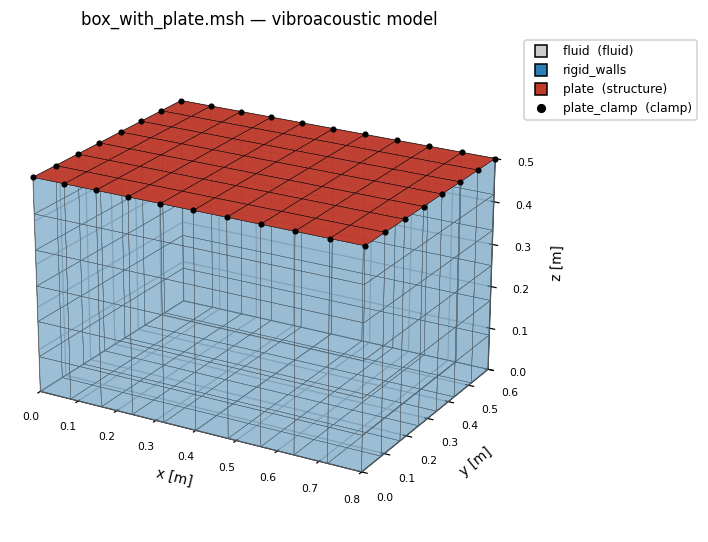

/Users/danielefabbri/Desktop/pycafe_new/Library/box_with_plate.msh  (vibroacoustic analysis)
--------------------------------------------------------------------------------------------
  616 nodes, 34 x Line 2, 344 x Quadrilateral 4, 420 x Hexahedron 8
  roles: fluid = 'fluid', structure = 'plate', clamp = 'plate_clamp'
  · interface conforming: 70 faces, one fluid element behind each
  · fluid element size: 85.7 / 85.7 / 85.7 mm (min / mean / max)
  · good to ~1% up to 308 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 200 Hz: 20.0 elements per wavelength, dispersion error ~0.41%
  · selectable boundaries: rigid_walls
  => usable
assembled: vibroacoustic -> ['acoustic', 'coupling', 'domains', 'interface', 'props', 'structural']


In [6]:
model = build_model(spec)

print(model["report"])
print("assembled:", model["analysis"], "->", sorted(model["system"]))

## 3. Picked a `.msh`: the `Library/` folder

`Library/` is the one folder a run is pointed at. It holds a mesh for every
geometry pyCAFE knows how to build, and next to them the CAD files and the
Nastran decks that come from outside, so the dialog has a single place to open
and the choice between "a mesh" and "a geometry" is made in it.

A mesh already carries its physical groups — that is what a `.msh` has and a CAD
file has not — so `MeshFile` takes it as it is and nothing is guessed.

Each file was built by `Library/make_library.py`, which states every case as a
`ModelSpec` at the `f_max` written in that script. **The frequency the mesh was
built for is the frequency it is good for**: asking a stored mesh for more than
that does not refine it, it only makes the validator warn.

In [7]:
WHAT = {".msh": "mesh, ready to use", ".stp": "CAD, WIP",
        ".step": "CAD, WIP", ".bdf": "Nastran deck, read as it is"}
for name in sorted(os.listdir(LIBRARY)):
    kind = WHAT.get(os.path.splitext(name)[1])
    if kind:
        size = os.path.getsize(os.path.join(LIBRARY, name)) / 1024
        print(f"  {name:28s} {size:8.0f} kB   {kind}")

print()
groups = list_groups(os.path.join(LIBRARY, "duct_with_flush_plate.msh"))

# The same dispatch as the dialog, for a script that already knows the path.
print()
print(geometry_from_file(os.path.join(LIBRARY, "duct_2d.msh")))

  Tubo_1m_1m.stp                     10 kB   CAD, meshed here
  Vibro_ac1.step                     25 kB   CAD, meshed here
  box_cavity.msh                    196 kB   mesh, ready to use
  box_with_plate.msh                 53 kB   mesh, ready to use
  demo_cavity.bdf                    43 kB   Nastran deck, read as it is
  duct_2d.msh                         3 kB   mesh, ready to use
  duct_with_flush_plate.msh          91 kB   mesh, ready to use
  plate.msh                           2 kB   mesh, ready to use



/Users/danielefabbri/Desktop/pycafe_new/Library/duct_with_flush_plate.msh:
  dim 1  plate_clamp          24 nodes (role clamp)
  dim 2  plate                49 nodes (role structure)
  dim 2  rigid_walls         431 nodes (boundary name)
  dim 2  inlet                49 nodes (boundary name)
  dim 2  outlet               49 nodes (boundary name)
  dim 3  fluid               931 nodes (role fluid)

duct_2d.msh: a mesh, used as it is (its physical groups already carry the roles).
MeshFile(path=PosixPath('/Users/danielefabbri/Desktop/pycafe_new/Library/duct_2d.msh'), rename={}, drop=())


The physical group names are the whole contract: `fluid`, `plate`,
`plate_clamp`, plus any free name (`inlet`, `outlet`, ...) the boundary
conditions select later. A mesh that comes from somewhere else and names them
differently is not rejected — it is renamed:

```python
MeshFile("from_ansys.msh", rename={"AIR": "fluid", "SKIN": "plate"},
         drop=("dead_group",))
```

To rebuild the folder, or to add a case to it, edit `CASES` in
`Library/make_library.py` and run it:

```bash
python Library/make_library.py
```

The same geometries can of course be stated inline, without going through a
file at all — that is the `Library` source, and it is what a parameter study
uses, since the dimensions are then arguments:

```python
spec = ModelSpec(geometry=Library("box_cavity", Lx=0.4, Ly=0.3, Lz=0.5),
                 fluid=AIR, f_max=500.0)
```

ModelSpec
  geometry     Library('box_cavity', Lx=0.4, Ly=0.3, Lz=0.5)
  fluid        air: rho0 = 1.204 kg/m3, c0 = 343.0 m/s
  f_max        300.0 Hz (lambda = 1143 mm)
  mesh size    114.3 mm (10 elements per wavelength)
  mesh file    00_box_cavity.msh

element counts derived from f_max, not written by hand:
  h = 114.3 mm -> 4 x 3 x 5 CHEXA8


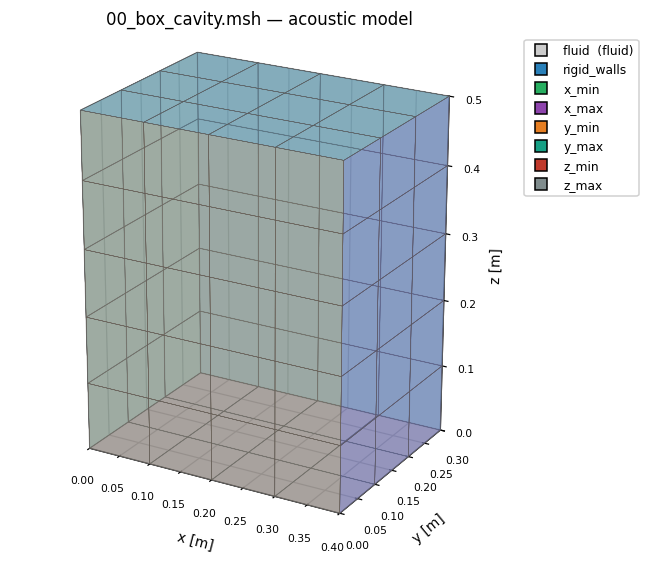

00_box_cavity.msh  (acoustic analysis)
--------------------------------------
  120 nodes, 94 x Quadrilateral 4, 60 x Hexahedron 8
  roles: fluid = 'fluid'
  · fluid element size: 100.0 / 100.0 / 100.0 mm (min / mean / max)
  · good to ~1% up to 264 Hz (13 elements per wavelength at c0 = 343 m/s)
  · at 300 Hz: 11.4 elements per wavelength, dispersion error ~1.25%
  · selectable boundaries: rigid_walls, x_max, x_min, y_max, y_min, z_max, z_min
  => usable


In [8]:
inline = ModelSpec(
    geometry=Library("box_cavity", Lx=0.4, Ly=0.3, Lz=0.5),
    fluid=AIR,
    f_max=300.0,
    work_dir=".",
    output_path="00_box_cavity.msh",
)
print(inline.describe())
print()
print("element counts derived from f_max, not written by hand:")
print(f"  h = {inline.element_size * 1e3:.1f} mm -> "
      f"{np.ceil(0.4 / inline.element_size):.0f} x "
      f"{np.ceil(0.3 / inline.element_size):.0f} x "
      f"{np.ceil(0.5 / inline.element_size):.0f} CHEXA8")

# preview() is build_model() without the matrices: mesh, check, look at it.
_path, _report = preview(inline)

---
## 4. What is not in this release

A CAD file and a Nastran deck are two other ways in, and pyCAFE reads both:
`CadFile` meshes a `.step` from `f_max`, `NastranFile` takes a `.bdf` as it
stands and reads the roles off its property cards. Neither is part of this
release, because the questions they raise — which entity is fluid, what unit
the file is drawn in, which property id is which role — are not settled yet.

The dialog therefore offers `.msh` and nothing else. The notebooks that use
the other two are in `WIP/`, and the files they read in `../Library/WIP/`.


## 6. The naming contract

Whatever the geometry came from, the mesh that leaves this stage speaks one
vocabulary. `describe_conventions()` prints it whenever it is needed.

In [13]:
print(describe_conventions())

Physical groups pyCAFE looks for by name:

  fluid        the acoustic domain: CHEXA8 in 3D, CQUAD4/8 in 2D
               also accepted: acoustic, domain

  plate        the structural domain (CQUAD4F shells); on a coupled mesh its elements are also the interface faces
               also accepted: structure, shell

  pml          the absorbing layer wrapped around the fluid; naming it is the whole switch — no group, no PML. Same element types as the fluid, and conforming with it
               also accepted: absorbing_layer

  plate_clamp  nodes where the structure is supported (clamped or pinned, chosen by the 'support' argument, not by the name)
               also accepted: clamp, fixed

Any other group is a free boundary name, selectable in AcousticBC. Common ones:

  rigid_walls  acoustically rigid walls; no BC needed, but handy to name
  opening      radiating or open face, usually given an anechoic impedance
  inlet        driven face, usually a prescribed normal velocity
  ou

## 7. Cheat sheet

```python
# 0. what run, and what the domains are made of
ANALYSIS = "vibroacoustic"                 # or "acoustic": the fluid alone
FLUID = AIR                                # the acoustic domain
STRUCTURE = aluminium(t=2e-3, support="clamped")   # the structural one

# 1. where is it?  (a dialog, or a typed path with no display; no answer
#    raises -- PYCAFE_FILE_GEOMETRY=<path> answers for a batch run)
geometry = ask_for_geometry()

# ... or state the source directly, when the script knows it:
geometry = Library("box_cavity", Lx=0.4, Ly=0.3, Lz=0.5)   # we build it
geometry = CadFile("duct.step", fluid=[1], structure=[3])  # we mesh it
geometry = NastranFile("cavity.bdf", fluid=[101], structure=[202])
geometry = MeshFile("Library/box_cavity.msh")

# 2. one object holds the whole input
spec = ModelSpec(geometry=geometry, analysis=ANALYSIS,
                 fluid=FLUID, structure=STRUCTURE, f_max=200.0)

# 3. which group is which domain, and what fills it
path, report = build_mesh(spec)
print(describe_domains(report, spec.fluid, spec.structure))

# 4. mesh, validate, draw, assemble
model = build_model(spec)          # preview(spec) stops before the matrices
```

Before trusting anything downstream, read the two things this stage prints: the
**picture** (is this the model I meant?) and the last line of the **report**
(`=> usable`, with the frequency the mesh is actually good for).

Where to go next: `01_cavity_acoustic_3d` (library box, modal), `02` (coupled
box), `03` (this STEP file, coupled duct), `04` (PML), `05` (non-conforming
coupling from CAD).